In [35]:
from datetime import timedelta
import matplotlib.pyplot as plt
import pandas as pd

df_pred = pd.read_csv('../../experiments/exp_2025-06-27/pred_ref/pred_92.csv',
                      index_col=0, parse_dates=True)
df_ref = pd.read_csv('../../experiments/exp_2025-06-27/pred_ref/ref_92.csv'
                     , index_col=0, parse_dates=True)

df_pred.drop(columns=['extra'], inplace=True)

In [36]:
df_pred

,1,2,3,4,5,6,7,8
dt,,,,,,,,
2022-06-26 00:00:00+00:00,0.808291,0.780604,0.773498,0.726276,0.750065,0.788955,0.775232,0.753808
2022-08-21 00:00:00+00:00,0.664357,0.670669,0.633820,0.622392,0.604118,0.566040,0.587042,0.550837
2022-10-16 00:00:00+00:00,0.444029,0.497074,0.492049,0.535214,0.552554,0.568445,0.613234,0.663222
2022-12-11 00:00:00+00:00,0.630362,0.629832,0.616276,0.585920,0.658175,0.699383,0.731154,0.739740
2023-02-05 00:00:00+00:00,0.759660,0.773946,0.821517,0.866736,0.844799,0.814593,0.752608,0.719885
2023-04-02 00:00:00+00:00,0.710287,0.698274,0.694212,0.698901,0.718110,0.702556,0.650774,0.612063
2023-05-28 00:00:00+00:00,0.678273,0.678063,0.720933,0.734609,0.724876,0.697722,0.671253,0.633519
2023-07-23 00:00:00+00:00,0.737106,0.743095,0.701440,0.752101,0.696766,0.742439,0.677821,0.704037
2023-09-17 00:00:00+00:00,0.655830,0.648563,0.623671,0.637020,0.645000,0.653468,0.685778,0.723390


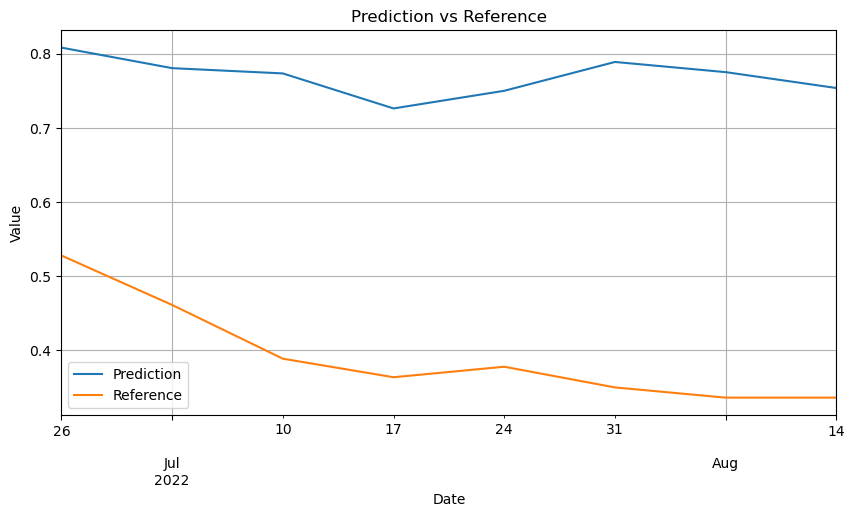

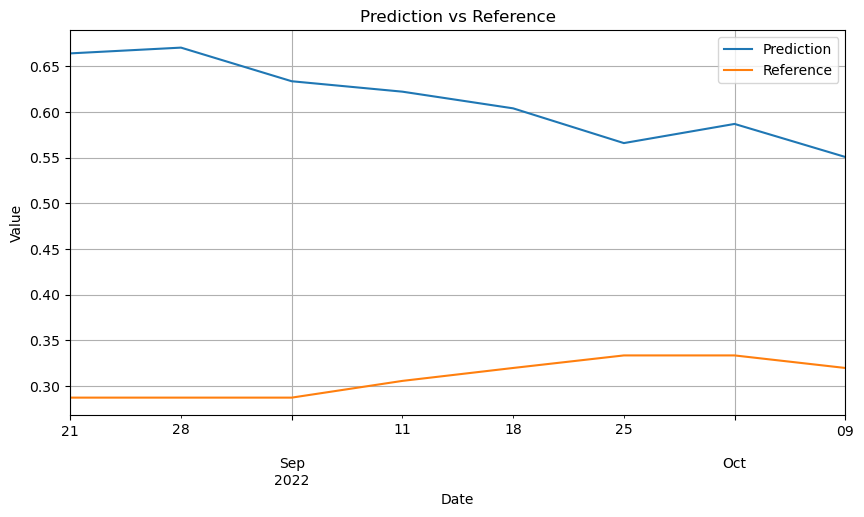

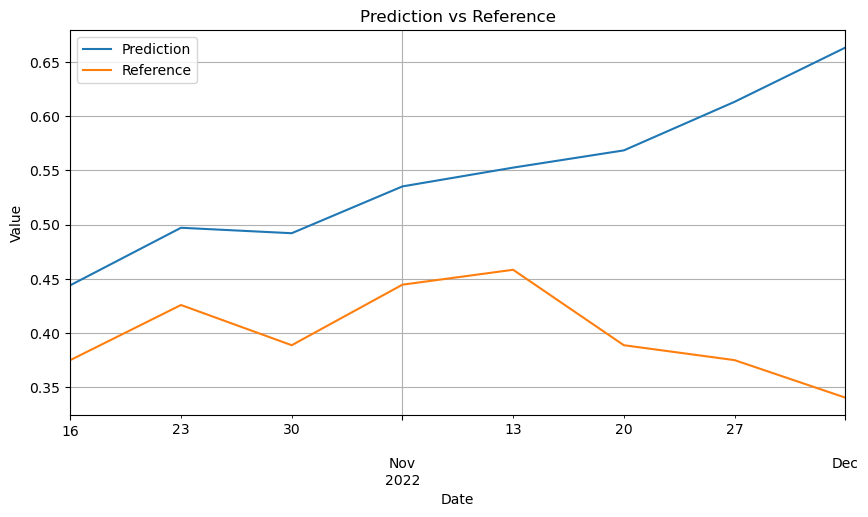

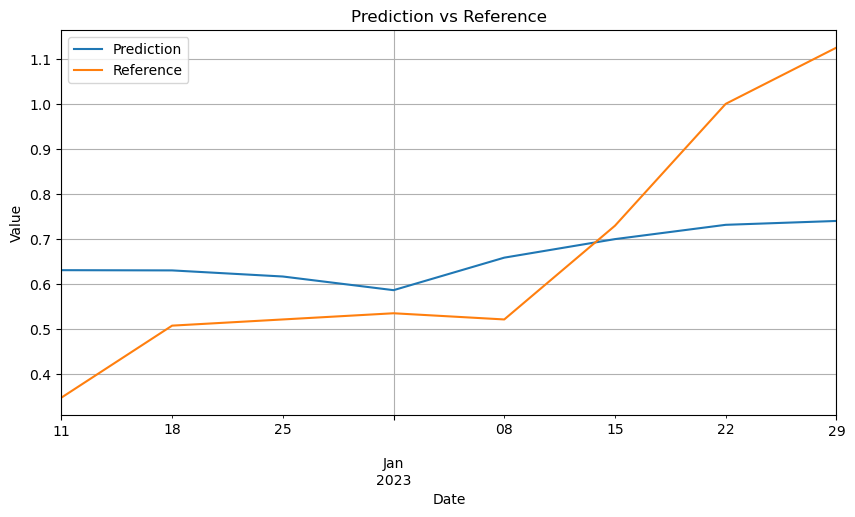

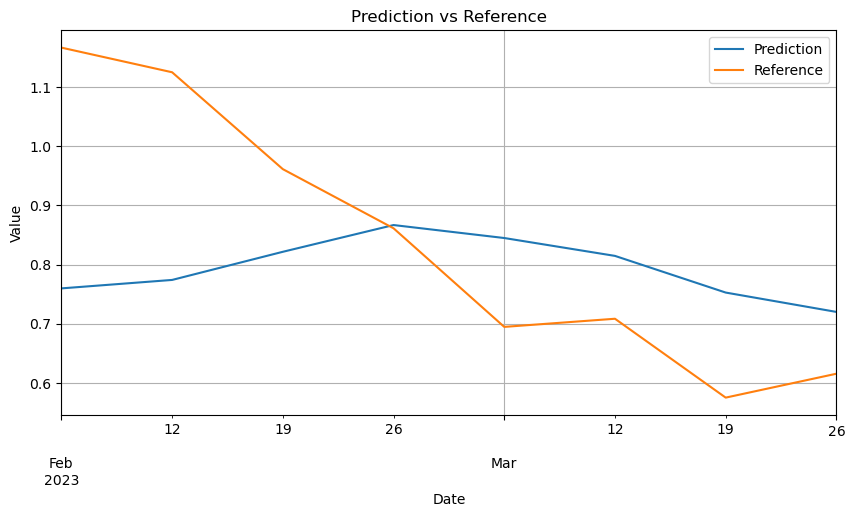

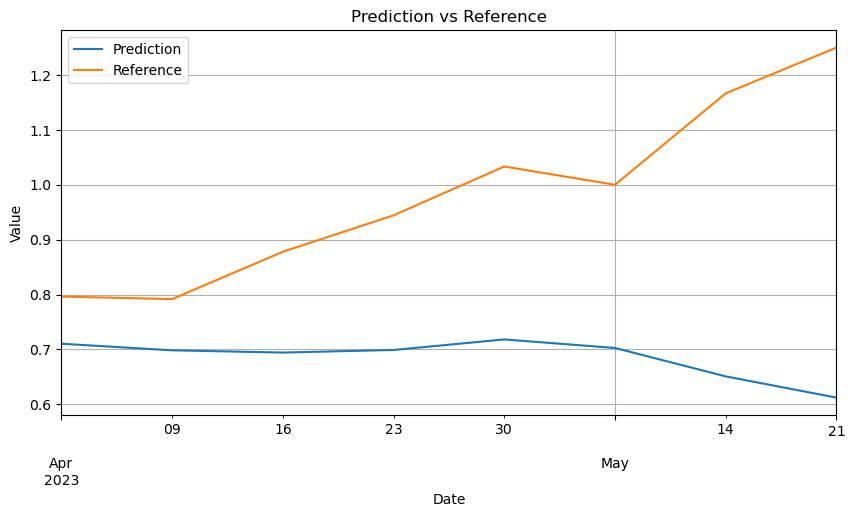

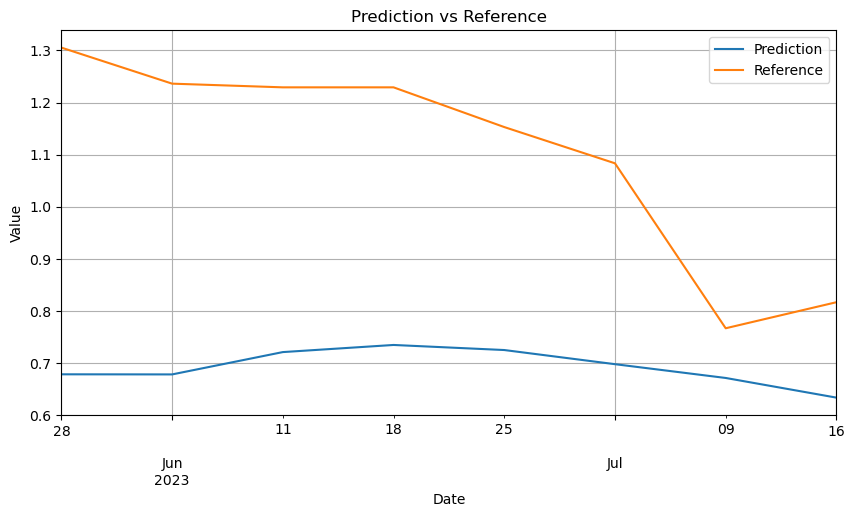

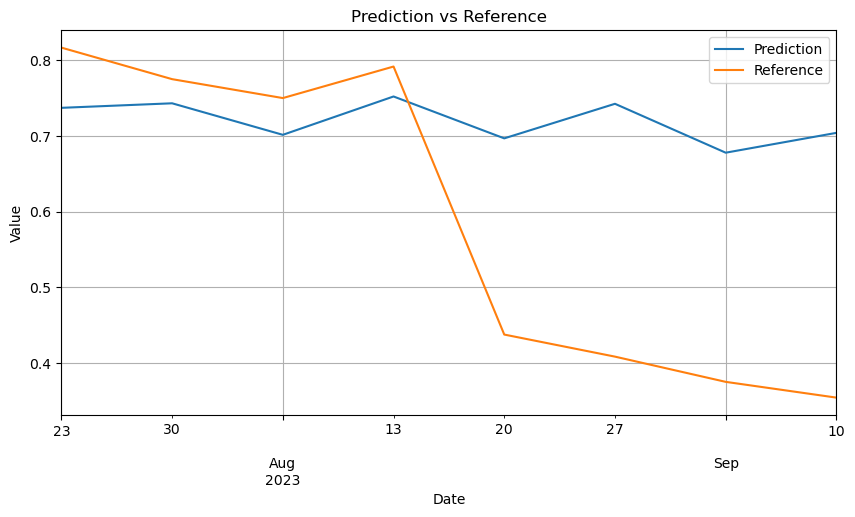

In [37]:
def traspose_series_from_df_row(df_pred, row):
    aux_df = df_pred.reset_index()
    transposed_values = aux_df.iloc[row,:].values
    #transposed_values.extend(aux_df.iloc[:,1].values)
    dates = [transposed_values[0] + timedelta(weeks=i) for i in range(len(transposed_values) -1)]
    transposed_series = pd.Series(transposed_values[1:], index=dates, name='val')
    return transposed_series

def plot_all_ref_pred(df_pred, df_ref):

    for i in range(8):
        traspose_series_pred = traspose_series_from_df_row(df_pred, i)
        traspose_series_ref = traspose_series_from_df_row(df_ref, i)

        #plot

        plt.figure(figsize=(10, 5))
        traspose_series_pred.plot(label='Prediction')
        traspose_series_ref.plot(label='Reference')
        plt.title('Prediction vs Reference')
        plt.xlabel('Date')
        plt.ylabel('Value')
        plt.legend()
        plt.grid()
        plt.show()

plot_all_ref_pred(df_pred, df_ref)